In [ ]:
import os, time
import numpy as np
import matplotlib.pyplot as plt
import cvxpy as cp

In [ ]:
!pip install ecos
!pip install scs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.1/222.1 kB 5.9 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
def buyer_best_response_cvx(v_i: np.ndarray,
                            price: np.ndarray,
                            q_i: float,
                            B_i: float) -> np.ndarray:
    """
    CVXPY solve of
        max  log(v_i · x)
        s.t. x >= 0 , (price + q_i)ᵀ x <= B_i
    """
    m = len(v_i)
    x = cp.Variable(m, nonneg=True)
    objective = cp.Maximize(cp.log(v_i @ x + 1e-12))
    constraint = [(price + q_i) @ x <= B_i]
    prob = cp.Problem(objective, constraint)
    try:
        prob.solve(solver="ECOS", warm_start=True)
    except cp.SolverError:
        prob.solve(solver="SCS")
    return x.value

In [ ]:
import os
import numpy as np
from google.colab import drive

# BƯỚC 1: Kết nối Google Drive (chỉ cần chạy 1 lần)
drive.mount('/content/drive', force_remount=True)

# BƯỚC 2: Cập nhật đường dẫn FACTOR_DIR
# Giả sử bạn đặt thư mục "valuation_out_23h_sigmoid"
# ngay trong "My Drive" (Drive của tôi)
FACTOR_DIR = "/content/drive/MyDrive/data/valuation_out_23h_sigmoid"

# --- Code của bạn bắt đầu từ đây ---
try:
    U = np.load(os.path.join(FACTOR_DIR, "user_factors.npy"))
    P = np.load(os.path.join(FACTOR_DIR, "item_factors.npy"))
    valuations = U @ P.T
    print(f"✓ Đã tải xong factors. Ma trận Valuations có shape: {valuations.shape}")

except Exception as e:
    print(f"⚠️  Lỗi khi tải file: {e}")
    print("Sử dụng ma trận valuations ngẫu nhiên...")
    valuations = np.random.rand(120, 12) + 0.5         # 120 buyers, 12 goods

# Synthetic
n_buyers, n_goods = valuations.shape
budgets = np.full(n_buyers, 10.0)
energy  = np.ones(n_buyers)
p0      = np.ones(n_goods)
q0      = np.ones(n_buyers)

obj_tol = 1e-3
num_iters = 10 ** 100
log_freq  = 100
X_tol   = 1e-2
seed = 2001

print(f"\nThiết lập hoàn tất. (n_buyers={n_buyers}, n_goods={n_goods})")

Mounted at /content/drive
✓ Đã tải xong factors. Ma trận Valuations có shape: (10, 24)

Thiết lập hoàn tất. (n_buyers=10, n_goods=24)


In [ ]:
# visualizing
def plot_trajectories(time_full, obj_full, X_norm_full, grad_full, grad_sgd,
                      time_sgd,  obj_sgd,  X_norm_sgd, X_full, X_sgd, gp_norm_hist_full, gq_norm_hist_full,
                      gp_norm_hist_sgd, gq_norm_hist_sgd):
    fig, ax = plt.subplots(7, 1, figsize=(18, 22))
    X_full = np.array(X_full)
    X_sgd = np.array(X_sgd)

    # Extract price and quantity in full gradient descent
    price_full = X_full[:, :len(p0)]
    quantity_full = X_full[:, len(p0):]
    # price_full shape: (T, m); quantity_full shape: (T, n)
    p_norm_full = np.linalg.norm(price_full, axis=1)      # shape (T,)
    q_norm_full = np.linalg.norm(quantity_full, axis=1)   # shape (T,)

    # Extract price and quantity in stochastic gradient descent
    price_sgd = X_sgd[:, :len(p0)]
    quantity_sgd = X_sgd[:, len(p0):]

    # price_sgd shape: (T, m); quantity_sgd shape: (T, n)
    p_norm_sgd = np.linalg.norm(price_sgd, axis=1)      # shape (T,)
    q_norm_sgd = np.linalg.norm(quantity_sgd, axis=1)   # shape (T,)

    # --- Objective vs Time ---
    ax[0].plot(time_full, obj_full, label="Full gradient")
    ax[0].plot(time_sgd,  obj_sgd,  label="1-sample SGD")
    ax[0].set_xlabel("Running time (s)")
    ax[0].set_ylabel("Objective value")
    ax[0].set_title("Objective value trajectories over time")
    ax[0].legend()

    # --- Gradient norm vs Time ---
    ax[1].plot(time_full, grad_full, label="Full gradient")
    ax[1].plot(time_sgd,  grad_sgd,  label="1-sample SGD")
    ax[1].set_xlabel("Running time (s)")
    ax[1].set_ylabel("Gradient norm")
    ax[1].set_title("Gradient-norm trajectories over time")
    ax[1].legend()

    # --- Zoomed-in X norm (p, q) vs Time ---
    ax[2].plot(time_full, X_norm_full, label="Full gradient")
    ax[2].plot(time_sgd,  X_norm_sgd,  label="1-sample SGD")
    ax[2].set_xlabel("Running time (s)")
    ax[2].set_ylabel("X norm")
    ax[2].set_title("X_norm (p, q) over time")
    ax[2].legend()

    # --- Price vs Time ---
    ax[3].plot(time_full, p_norm_full, label="Full gradient")
    ax[3].plot(time_sgd,  p_norm_sgd,  label="1-sample SGD")
    ax[3].set_xlabel("Running time (s)")
    ax[3].set_ylabel("Price")
    ax[3].set_title("Price over time")
    ax[3].legend()

    # --- Quantity vs Time ---
    ax[4].plot(time_full, q_norm_full, label="Full gradient")
    ax[4].plot(time_sgd,  q_norm_sgd,  label="1-sample SGD")
    ax[4].set_xlabel("Running time (s)")
    ax[4].set_ylabel("Quantity")
    ax[4].set_title("Quantity over time")
    ax[4].legend()

    ax[5].plot(time_full, gp_norm_hist_full, label="Full gradient")
    ax[5].plot(time_sgd,  gp_norm_hist_sgd,  label="1-sample SGD")
    ax[5].set_xlabel("Running time (s)")
    ax[5].set_ylabel("g_p norm (‖g_p‖)")
    ax[5].set_title("Price Gradient Norm over time")
    ax[5].legend()

    ax[6].plot(time_full, gq_norm_hist_full, label="Full gradient")
    ax[6].plot(time_sgd,  gq_norm_hist_sgd,  label="1-sample SGD")
    ax[6].set_xlabel("Running time (s)")
    ax[6].set_ylabel("g_q norm (‖g_q‖)")
    ax[6].set_title("Quantity Gradient Norm over time")
    ax[6].legend()

    plt.tight_layout()
    plt.show()

## Terminate with ||x_new - x_old|| < tol

In [ ]:
def one_sample_sgd_fastlog(
        energy, q0, valuations, budgets, p0,
        lr_p=0.05, lr_q=0.05,
        num_iters=1000, seed=0,
        log_freq=50, X_tol=1, time_limit=120.0):
    """
    Phiên bản one-sample SGD tối ưu (fastlog):
    - Cập nhật incremental, không tính lại toàn bộ X khi log.
    - Dừng theo giới hạn thời gian (time_limit giây).
    - Trả về output giống hệt one_sample_sgd cũ:
        obj_hist, X_hist, grad_hist, time_hist, X_norm_hist
    """
    rng = np.random.default_rng(seed)
    n, m = valuations.shape

    # --- khởi tạo ---
    p = p0.astype(float).copy()
    q = q0.astype(float).copy()

    X = np.zeros((n, m)) # print X
    util = np.zeros(n)
    for j in range(n):
        X[j] = buyer_best_response_cvx(valuations[j], p, q[j], budgets[j])
        util[j] = valuations[j] @ X[j]

    D = X.sum(axis=0)
    slack = energy - X.sum(axis=1)

    obj_hist, X_hist, grad_hist, time_hist, X_norm_hist = [], [], [], [], []
    real_allocation_hist = []
    gp_norm_hist = []  # List mới để lưu g_p_full
    gq_norm_hist = []  # List mới để lưu g_q_full

    t0 = time.perf_counter()

    # --- vòng lặp SGD ---
    for t in range(1, num_iters + 1):
        elapsed = time.perf_counter() - t0


        # chọn buyer ngẫu nhiên
        i = int(rng.integers(n))

        # cập nhật tổng cầu (D) và trạng thái buyer i
        D -= X[i]
        x_i_new = buyer_best_response_cvx(valuations[i], p, q[i], budgets[i])
        X[i] = x_i_new
        util[i] = valuations[i] @ x_i_new
        slack[i] = energy[i] - x_i_new.sum()
        D += x_i_new

        # gradient theo p và q_i
        g_p = np.ones(m) - n * x_i_new
        g_q_i = slack[i]

        # bước học
        alpha = lr_p / np.sqrt(t)
        beta = lr_q / np.sqrt(t)
        p = np.maximum(p - alpha * g_p, 0.0)
        q[i] = max(q[i] - beta * g_q_i, 0.0)

        # log định kỳ
        if t % log_freq == 0 or t == 1:
            g_p_full = np.ones(m) - D
            g_q_full = slack
            grad_norm = np.linalg.norm(np.concatenate([g_p_full, g_q_full]))
            obj = p.sum() + (q * energy).sum() + (budgets * np.log(util + 1e-12)).sum()

            obj_hist.append(obj)
            grad_hist.append(grad_norm)
            X_hist.append(np.concatenate([p, q]))
            time_hist.append(elapsed)
            real_allocation_hist.append(X.copy())
            gp_norm_hist.append(np.linalg.norm(g_p_full))
            gq_norm_hist.append(np.linalg.norm(g_q_full))

            # Save pair (p, q) norm history for convergence check
            X_norm_hist.append(np.linalg.norm(np.concatenate([p, q])))

            print(f"[SGD-fastlog] iter={t:7d}  time={elapsed:6.2f}s  "
                  f"obj={obj:10.4f}  ‖g‖={grad_norm:.2e}")

        '''--- termination conditions --- '''
        if len(X_hist) > 1:
                delta_X = np.linalg.norm(X_hist[-1] - X_hist[-2])
                if delta_X <= X_tol:
                    print("SGD-fastlog ‖ΔX‖ < tol → stopping.")
                    break

    return obj_hist, X_hist, grad_hist, time_hist, X_norm_hist, real_allocation_hist, gp_norm_hist, gq_norm_hist

In [ ]:
def full_grad_descent(energy, q0, valuations, budgets, p0,
                      lr_p=0.05, lr_q=0.05,
                      num_iters=3000, log_freq=50, X_tol=1):
    n, m = valuations.shape
    p = p0.astype(float).copy()
    q = q0.astype(float).copy()
    obj_hist, X_hist, grad_hist, time_hist, X_norm_hist = [], [], [], [], []
    real_allocation_hist = []
    gp_norm_hist = []  # List mới để lưu g_p
    gq_norm_hist = []  # List mới để lưu g_q
    t0 = time.perf_counter()

    for t in range(1, num_iters + 1):
        X = np.array([buyer_best_response_cvx(valuations[j], p, q[j], budgets[j])
                      for j in range(n)])
        g_p = np.ones(m) - X.sum(axis=0)
        g_q = energy - X.sum(axis=1)

        alpha = lr_p / np.sqrt(t);  beta = lr_q / np.sqrt(t)
        p = np.maximum(p - alpha * g_p, 0.0)
        q = np.maximum(q - beta * g_q, 0.0)

        if t % log_freq == 0 or t == 1:
            gp_norm_hist.append(np.linalg.norm(g_p.copy()))  # Thêm g_p (dùng .copy() cho an toàn)
            gq_norm_hist.append(np.linalg.norm(g_q.copy()))  # Thêm g_q (dùng .copy() cho an toàn)
            grad_norm = np.linalg.norm(np.concatenate([g_p, g_q]))
            util = (valuations * X).sum(axis=1)
            obj = p.sum() + (q * energy).sum() + (budgets * np.log(util + 1e-12)).sum()
            obj_hist.append(obj)
            grad_hist.append(grad_norm)
            X_hist.append(np.concatenate([p, q]))
            real_allocation_hist.append(X.copy())

            running_time = time.perf_counter() - t0
            time_hist.append(running_time)
            print(f"[FULL] iter={t:>7d}  time={running_time:6.2f}s  obj={obj:10.4f}  ‖g‖={grad_norm:.2e}")

            # Save pair (p, q) norm history for convergence check
            X_norm_hist.append(np.linalg.norm(np.concatenate([p, q])))

            # --- termination conditions ---
            if len(X_hist) > 1:
                delta_X = np.linalg.norm(X_hist[-1] - X_hist[-2])
                if delta_X <= X_tol:
                    print("FULL ‖ΔX‖ < tol → stopping.")
                    break

    return obj_hist, X_hist, grad_hist, time_hist, X_norm_hist, real_allocation_hist, gp_norm_hist, gq_norm_hist

# Different budget

In [ ]:
# Rich Poor buyers
n_buyers, n_goods = valuations.shape

'''
---------- Random budgets between 5 and 30 ----------
'''
# Different budget. Rich and poor buyers
valuations = U @ P.T
budgets = np.random.uniform(5.0, 30.0, size=n_buyers)
energy  = np.ones(n_buyers)
p0      = np.ones(n_goods)
q0      = np.ones(n_buyers)

In [ ]:
t0 = time.perf_counter()
obj_sgd2, X_sgd2,  grad_sgd2, time_sgd2, X_norm_sgd2, sgd_allocation2, gp_norm_hist_sgd2, gq_norm_hist_sgd2 = one_sample_sgd_fastlog(
        energy, q0, valuations, budgets, p0,
        lr_p=0.1, lr_q=0.1,
        num_iters=num_iters, seed=seed,
        log_freq=log_freq, X_tol=X_tol)
t_sgd = time.perf_counter() - t0

t0 = time.perf_counter()
obj_full2, X_full2, grad_full2, time_full2, X_norm_full2, full_allocation2, gp_norm_hist_full2, gq_norm_hist_full2 = full_grad_descent(
        energy, q0, valuations, budgets, p0,
        lr_p=0.1, lr_q=0.1,
        num_iters=num_iters,
        log_freq=log_freq, X_tol=X_tol)
t_full = time.perf_counter() - t0

print(f"\nSGD finished in {t_sgd:.2f} s")
print(f"Full gradient finished in {t_full:.2f} s")
print(f"Speed-up = {t_full / t_sgd:.1f}× (wall-clock)\n")

[SGD-fastlog] iter=      1  time=  0.00s  obj=  887.8543  ‖g‖=6.09e+01
[SGD-fastlog] iter=    100  time=  2.26s  obj=  757.3635  ‖g‖=1.09e+01
[SGD-fastlog] iter=    200  time=  5.77s  obj=  744.3646  ‖g‖=9.94e+00
[SGD-fastlog] iter=    300  time=  7.39s  obj=  738.5234  ‖g‖=8.97e+00
[SGD-fastlog] iter=    400  time=  8.32s  obj=  734.4685  ‖g‖=8.37e+00
[SGD-fastlog] iter=    500  time=  9.27s  obj=  731.6938  ‖g‖=8.08e+00
[SGD-fastlog] iter=    600  time= 10.23s  obj=  729.0098  ‖g‖=7.75e+00
[SGD-fastlog] iter=    700  time= 11.65s  obj=  727.5635  ‖g‖=7.96e+00
[SGD-fastlog] iter=    800  time= 13.07s  obj=  725.9860  ‖g‖=7.14e+00
[SGD-fastlog] iter=    900  time= 14.39s  obj=  724.3907  ‖g‖=7.90e+00
[SGD-fastlog] iter=   1000  time= 15.34s  obj=  723.0002  ‖g‖=7.17e+00
[SGD-fastlog] iter=   1100  time= 16.33s  obj=  721.7479  ‖g‖=7.81e+00
[SGD-fastlog] iter=   1200  time= 17.31s  obj=  720.8613  ‖g‖=6.36e+00
[SGD-fastlog] iter=   1300  time= 18.29s  obj=  719.8590  ‖g‖=6.93e+00
[SGD-f

/usr/local/lib/python3.12/dist-packages/cvxpy/problems/problem.py:1510: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


[FULL] iter=  15200  time=1626.71s  obj=  626.9838  ‖g‖=3.59e+00
[FULL] iter=  15300  time=1636.89s  obj=  626.9576  ‖g‖=3.82e+00
[FULL] iter=  15400  time=1647.35s  obj=  626.9309  ‖g‖=3.71e+00
[FULL] iter=  15500  time=1657.72s  obj=  626.9004  ‖g‖=3.45e+00
[FULL] iter=  15600  time=1667.20s  obj=  626.8782  ‖g‖=3.63e+00
[FULL] iter=  15700  time=1677.46s  obj=  626.8500  ‖g‖=3.46e+00
[FULL] iter=  15800  time=1688.03s  obj=  626.8255  ‖g‖=3.62e+00
[FULL] iter=  15900  time=1698.59s  obj=  626.8002  ‖g‖=3.63e+00
[FULL] iter=  16000  time=1707.73s  obj=  626.7751  ‖g‖=3.53e+00
[FULL] iter=  16100  time=1718.15s  obj=  626.7530  ‖g‖=3.52e+00
[FULL] iter=  16200  time=1728.80s  obj=  626.7288  ‖g‖=3.82e+00
[FULL] iter=  16300  time=1739.35s  obj=  626.7040  ‖g‖=3.72e+00
[FULL] iter=  16400  time=1748.50s  obj=  626.6818  ‖g‖=3.64e+00
[FULL] iter=  16500  time=1758.87s  obj=  626.6603  ‖g‖=3.68e+00
[FULL] iter=  16600  time=1769.35s  obj=  626.6369  ‖g‖=3.57e+00
[FULL] iter=  16700  time

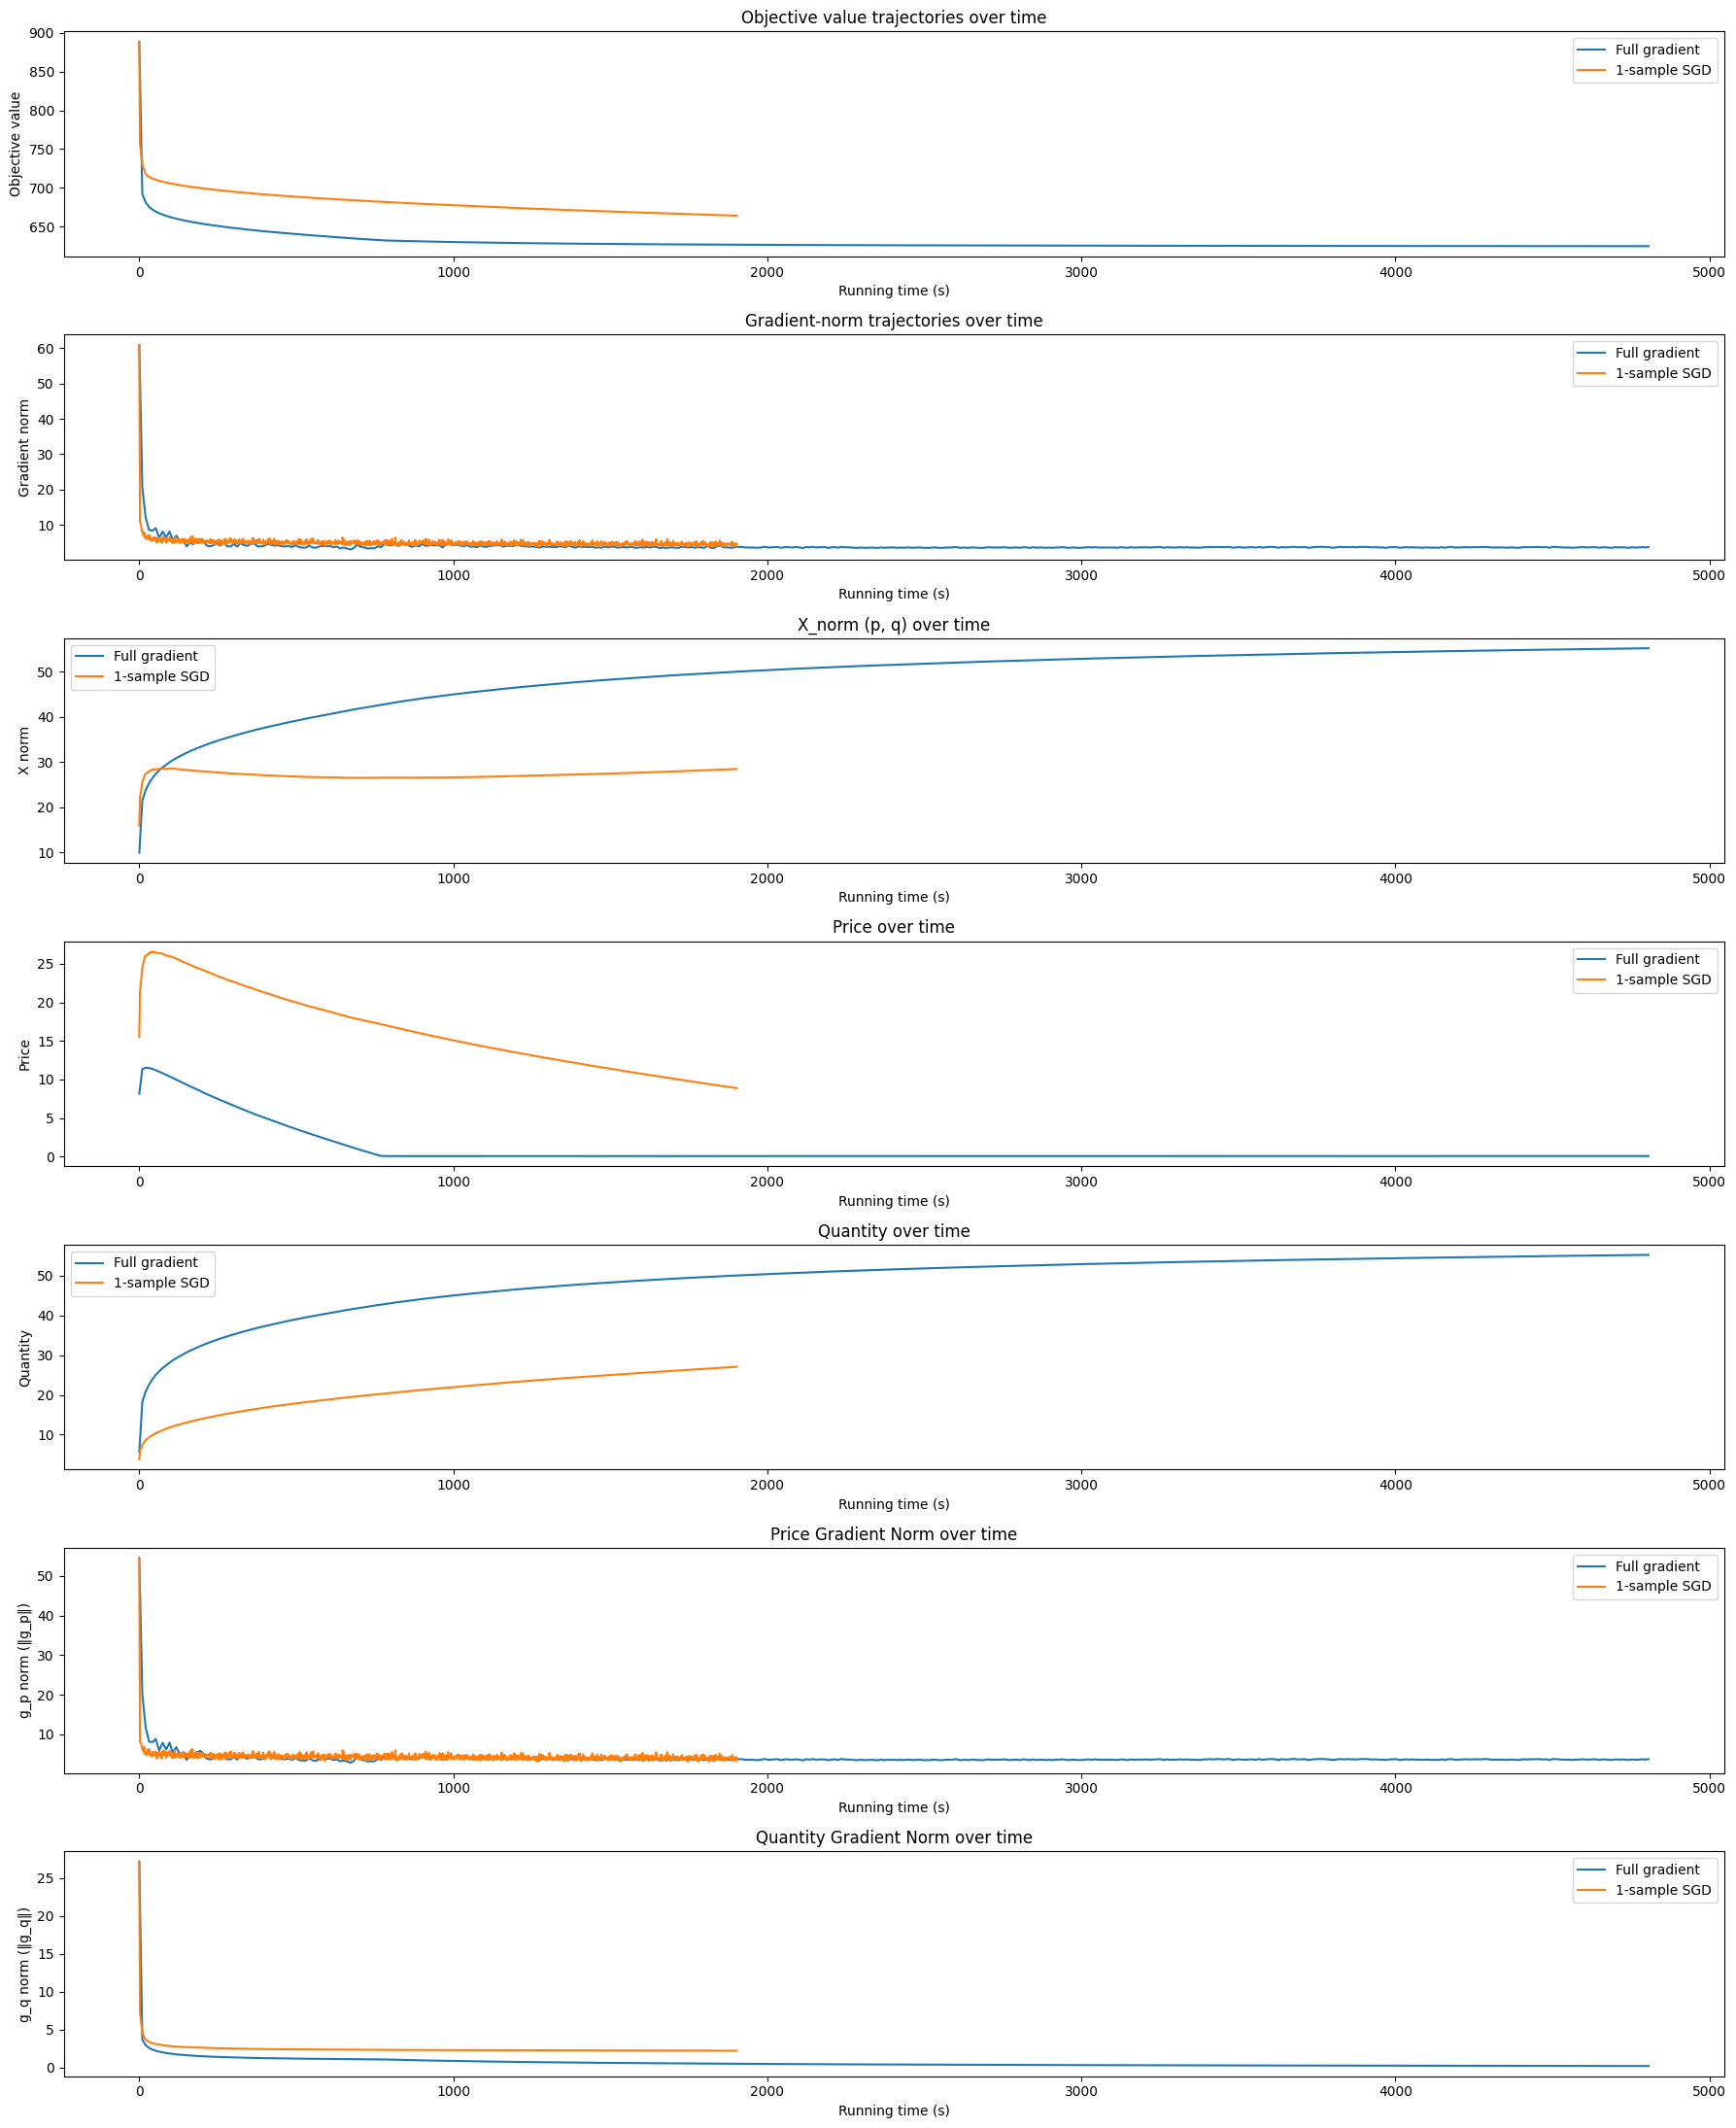

In [ ]:
plot_trajectories(time_full2, obj_full2, X_norm_full2, grad_full2, grad_sgd2, time_sgd2,  obj_sgd2,  X_norm_sgd2, X_full2, X_sgd2, gp_norm_hist_full2, gq_norm_hist_full2,
                      gp_norm_hist_sgd2, gq_norm_hist_sgd2)

In [ ]:
# 1. Gom TẤT CẢ các biến bạn muốn lưu vào một dictionary
import pickle
all_results = {
    'sgd_run': {
        'obj': obj_sgd2,
        'X_final': X_sgd2,
        'grad_final': grad_sgd2,
        'time_log': time_sgd2,
        'X_norm_log': X_norm_sgd2,
        'alloc_final': sgd_allocation2,
        'gp_hist': gp_norm_hist_sgd2,
        'gq_hist': gq_norm_hist_sgd2,
        'total_time': t_sgd # Lưu cả thời gian chạy
    },
    'full_run': {
        'obj': obj_full2,
        'X_final': X_full2,
        'grad_final': grad_full2,
        'time_log': time_full2,
        'X_norm_log': X_norm_full2,
        'alloc_final': full_allocation2,
        'gp_hist': gp_norm_hist_full2,
        'gq_hist': gq_norm_hist_full2,
        'total_time': t_full
        # ... (thêm các biến của full_grad vào đây)
    },
    'parameters': { # Lưu cả tham số để đối chiếu
        'lr_p': 0.1,
        'seed': seed,
        'obj_tol': 1e-3,
        'num_iters' : 10 ** 100,
        'log_freq' : 100,
        'X_tol'   : 1e-5,
        'seed' : 2001,
        'timE' : 7200
    },
    'data': { # Lưu cả tham số để đối chiếu
        'n_buyers' : n_buyers, 'n_goods' : n_goods,
        'budgets' : budgets,
        'energy'  : energy,
        'p0'      : p0,
        'q0'      : q0,
        'Description': "Different budget budgets = np.random.uniform(5.0, 30.0, size=n_buyers)"
}}

# 2. Định nghĩa đường dẫn và lưu file
save_path_pickle = '/content/drive/MyDrive/experiment_result/z_termination/various_budget_data.pkl'

# 'wb' nghĩa là "write binary" (ghi nhị phân)
with open(save_path_pickle, 'wb') as f:
    pickle.dump(all_results, f)

print(f"Đã lưu thành công TOÀN BỘ kết quả vào: {save_path_pickle}")

Đã lưu thành công TOÀN BỘ kết quả vào: /content/drive/MyDrive/experiment_result/z_termination/various_budget_data.pkl
